### Build a Basic Chatbot with LangGraph(Graph API)

In [26]:
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [27]:
class State(TypedDict):
    # Messages have the type "list". The "add_messages function"
    # in the annoation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [28]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [29]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(
    model="qwen/qwen3-32b"
)

In [30]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001678E2FF100>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001678E2FFA80>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [31]:
llm=init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001678E3A8DD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001678E3A96D0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [32]:
# Node Functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [33]:
graph_builder=StateGraph(State)

## Adding Node
graph_builder.add_node("llmchatbot",chatbot)

## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)


## Compile the graph
graph=graph_builder.compile()

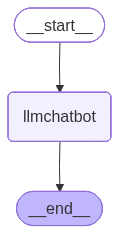

In [34]:
## Visualize the graph

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [37]:
response=graph.invoke({"messages":"Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='64203b79-3c68-4ba7-886e-56c6fcf3a6d3'),
  AIMessage(content='<think>\nOkay, the user just said "Hi". That\'s pretty casual. I need to respond in a friendly and welcoming way. Maybe start with a greeting and offer help. Let me check the guidelines. I should keep it conversational, no markdown. Let me make sure I\'m not too formal. Alright, something like, "Hello! How can I assist you today?" That should work. Let me add an emoji to keep it warm. Maybe a smiley. Yeah, that\'s good.\n</think>\n\nHello! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 9, 'total_tokens': 125, 'completion_time': 0.244403693, 'completion_tokens_details': None, 'prompt_time': 0.000368684, 'prompt_tokens_details': None, 'queue_time': 0.049617705, 'total_time': 0.244772377}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2'

In [40]:
response["messages"][-1].content

'<think>\nOkay, the user just said "Hi". That\'s pretty casual. I need to respond in a friendly and welcoming way. Maybe start with a greeting and offer help. Let me check the guidelines. I should keep it conversational, no markdown. Let me make sure I\'m not too formal. Alright, something like, "Hello! How can I assist you today?" That should work. Let me add an emoji to keep it warm. Maybe a smiley. Yeah, that\'s good.\n</think>\n\nHello! 😊 How can I assist you today?'

In [42]:
for event in graph.stream({"messages":"Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user asked, How are you? I should respond in a friendly way, right? They might want to start a conversation, so I need to sound welcoming and approachable. Let me think about a good reply.

Hmm, maybe I can say something like, I'm doing great! How about you? That's open-ended and lets them share their own feelings. It shows I care about their well-being too. Yeah, that sounds good.

Wait, but should I mention if I have any specific emotions? Oh right, I'm an AI, so maybe I shouldn't pretend to have feelings. Better to be honest while still being friendly. Like, I'm functioning well! Thanks for asking. How are you feeling today? That's clearer and keeps the conversation going.

I should also keep the tone warm and positive. Maybe add an emoji to make it feel more personable. Let me check the guidelines. Oh, emojis are allowed as they can help convey emotions better in text. So something like, I'm doing great! 😊 How about you? That should work.

Also, considering cultur